In [ ]:
import os, sys

if not os.path.exists("sis1_group7"):
    !git clone https://github.com/BradDanAlexandru/sis1_group7.git

sys.path.insert(0, "sis1_group7")

**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [49]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [50]:
# Write the code here
filepath = "audio/136954__stomachache__gsharp1.wav"
ref, fs = load_audio(filepath)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

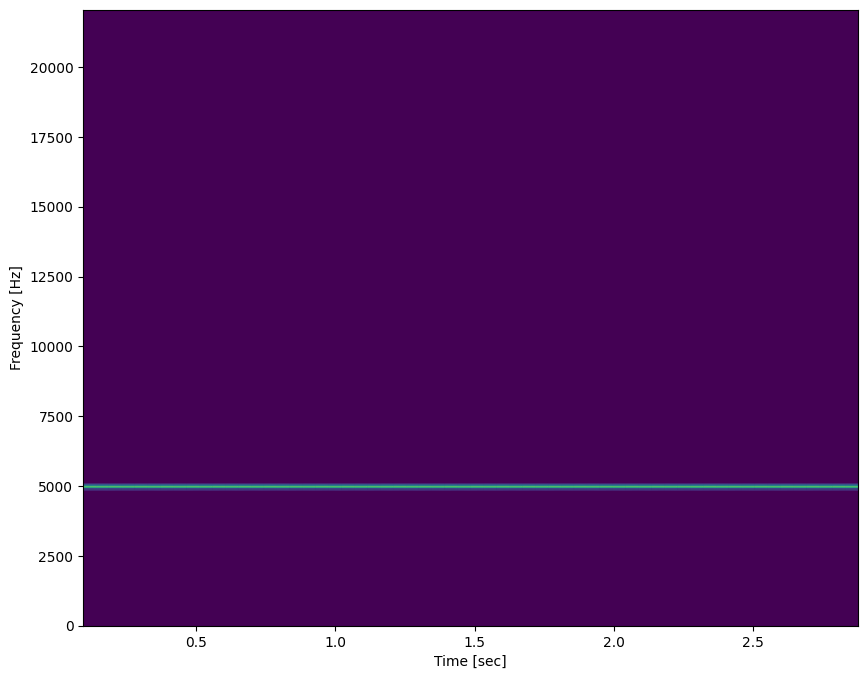

In [77]:
from scipy import signal

#define signal
A = 0.8
f0 = 5000.0
phi = np.pi/2
fs = 44100
t = np.arange(0, 3, 1.0/fs)
x = A * np.cos(2*np.pi*f0*t + phi)

# calculate the spectrogram
window_length = 8192
ff, tt, S = signal.spectrogram(x, fs, nperseg=window_length, noverlap=window_length/2)

# plot the spectrogram
plt.figure(figsize=(10,8))
plot_spectrogram(ff, tt, S)
plt.show()

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [78]:
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


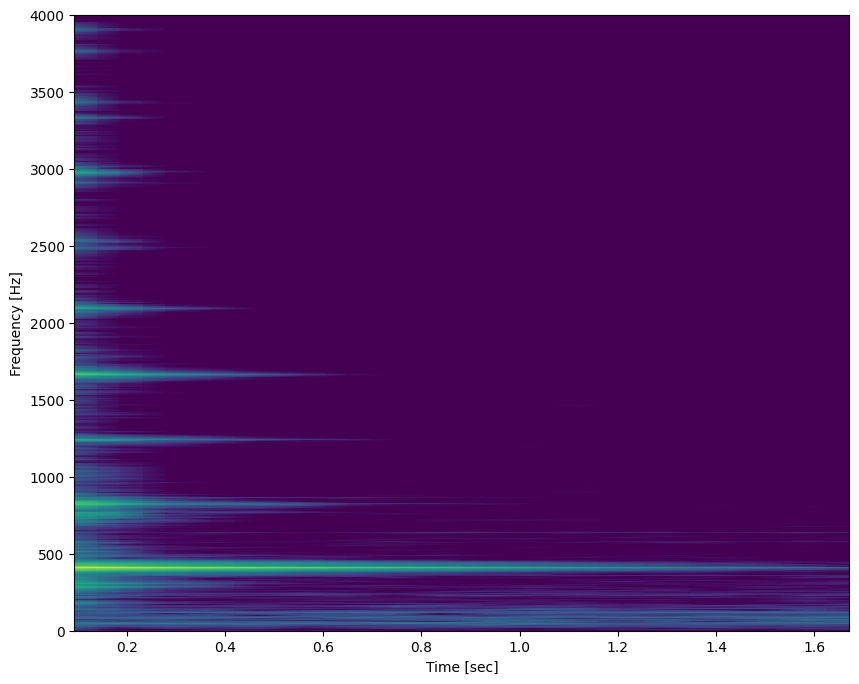

In [79]:
# Write the code here
A = 0.0946
f0 = 416.037
fs = 44100
phi = ((0.317277-0.31608)/0.0024266)*2* np.pi #del ej 3.1 lab1
t = np.arange(0, 1, 1.0/fs)


# calculate the spectrogram
window_length = 8192
ff, tt, S = signal.spectrogram(ref, fs, nperseg=window_length, noverlap=(window_length/2))

# plot the spectrogram
plt.figure(figsize=(10,8))
plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])
plt.show()

1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [80]:
# Write the code here
plot_spectrum_at(ff, tt, S, 0.31608)

1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [81]:
weights = [1, 0.0264, 0.0143, 0.032,0.005, 0.0005, 0.00095] # Fill this list with the measured weights

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [82]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

In [83]:
from IPython.display import Audio
# Write the code here
T0 = 1/f0
t_start = 0.31608#inicio del fragmento estable
num_periods = 8
t_end = t_start + num_periods * T0
synthetic_signal = synthesize(f0, phi, weights, t)
plot_signals([ref, s/10], fs, t_start, t_end, name = ["reference signal", "synthesized signal"])
Audio(s, rate=fs)

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [84]:
# Write the code here

window_length = 8192
ff, tt, S_synt = signal.spectrogram(synthetic_signal, fs, nperseg=window_length, noverlap=(window_length/2))
plot_spectrum_at(ff, tt, [S, S_synt], 0.31608)

2.3. Compare the spectrograms of the two signals. What are the main differences?

Observing the plot, we see that the spectral peaks that coincide are precisely those that were used in the weight initialization (amplitudes) for the creation of the synthetic signal. This indicates that the initial spectral structure is consistent between both signals.

Mismatch Due to Amplitude:
However, as the amplitude of the original signal at other frequencies is not reflected in the weights used for synthesis, the spectrum of the created (synthetic) signal drops and ceases to match the original signal's spectrum. This highlights that the synthetic spectrum only reproduces the frequency components that were explicitly provided to it via the weights.

Difference Due to Noise:
Furthermore, a notable difference is appreciated in the presence of additional peaks. The original signal exhibits numerous small,  spectral peaks, which are produced by the noise present in the recording. In contrast, the synthetic signal lacks these peaks because noise was not introduced during its creation process.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [85]:
Audio(synthetic_signal, rate=fs)

In [86]:
Audio(ref, rate=fs)



1. Timbre and Richness (Due to Missing Amplitudes)
Original Audio: Sounds fuller and richer. It contains all the natural components of the recorded sound (including the frequencies where the synthetic signal's spectrum drops off).

Synthetic Audio: Sounds pure or more artificial. Since its spectrum only includes the frequencies whose weights I initialized, it's missing the complex tones and  components present in the original signal. It sounds like a simplified, almost "perfect" version of the sound, lacking natural complexity.

2. Clarity and Cleanliness (Due to Noise)
Original Audio: can contain a constant hiss, hum, or static in the background, which is the audible manifestation of the noise peaks observed in its spectrum (i do not really appreciate it but it may can).

Synthetic Audio: Will sound perfectly clean and silent between the intended tones. Since no noise was introduced, with any background hiss or sounds; only the pure tones corresponding to the fundamental frequency and the specified harmonics.
